<a href="https://colab.research.google.com/github/Vronska-Anhelina/University-app-/blob/main/Clustering_of_teachers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from google.colab import drive

drive.mount("/content/drive")

import zipfile

zip_path = "/content/drive/MyDrive/university_schema.zip"
extract_path = "/content/university_schema"
with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(extract_path)
path = extract_path
teachers = pd.read_csv(f"{path}/teachers.csv")
course_offerings = pd.read_csv(f"{path}/course_offerings.csv")
lessons = pd.read_csv(f"{path}/lessons.csv")
grades = pd.read_csv(f"{path}/grades.csv")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
dataframe = grades.merge(course_offerings, on = "course_offering_id", how = "inner")
dataframe = dataframe.merge(teachers, on = "teacher_id", how = "inner")
dataframe.head()

,student_id,course_offering_id,value,date,group_id_x,course_id,group_id_y,teacher_id,semester_id,c,name,cathedra
0,1,1,71.4,2022-11-16,1,19,1,50,1,4,пан Андрій Гайворонський,Physics
1,2,1,90.6,2022-09-10,1,19,1,50,1,4,пан Андрій Гайворонський,Physics
2,3,1,66.5,2022-09-08,1,19,1,50,1,4,пан Андрій Гайворонський,Physics
3,4,1,72.7,2022-10-16,1,19,1,50,1,4,пан Андрій Гайворонський,Physics
4,5,1,70.0,2022-12-03,1,19,1,50,1,4,пан Андрій Гайворонський,Physics


In [5]:
dataframe = dataframe.drop("c", axis = 1)
dataframe = dataframe.drop("group_id_y", axis = 1)
dataframe.head()

,student_id,course_offering_id,value,date,group_id_x,course_id,teacher_id,semester_id,name,cathedra
0,1,1,71.4,2022-11-16,1,19,50,1,пан Андрій Гайворонський,Physics
1,2,1,90.6,2022-09-10,1,19,50,1,пан Андрій Гайворонський,Physics
2,3,1,66.5,2022-09-08,1,19,50,1,пан Андрій Гайворонський,Physics
3,4,1,72.7,2022-10-16,1,19,50,1,пан Андрій Гайворонський,Physics
4,5,1,70.0,2022-12-03,1,19,50,1,пан Андрій Гайворонський,Physics


In [6]:
lessons_count = lessons.groupby("course_offering_id").size().reset_index(name = "lessons_count")
dataframe = dataframe.merge(lessons_count, on = "course_offering_id")
dataframe.head()

,student_id,course_offering_id,value,date,group_id_x,course_id,teacher_id,semester_id,name,cathedra,lessons_count
0,1,1,71.4,2022-11-16,1,19,50,1,пан Андрій Гайворонський,Physics,14
1,2,1,90.6,2022-09-10,1,19,50,1,пан Андрій Гайворонський,Physics,14
2,3,1,66.5,2022-09-08,1,19,50,1,пан Андрій Гайворонський,Physics,14
3,4,1,72.7,2022-10-16,1,19,50,1,пан Андрій Гайворонський,Physics,14
4,5,1,70.0,2022-12-03,1,19,50,1,пан Андрій Гайворонський,Physics,14


In [7]:
dataframe = dataframe.sort_values(["student_id", "date"])
dataframe["student_avg_grade"] = (
    dataframe.groupby("student_id")["value"].mean())
dataframe["student_avg_grade"] = dataframe["student_avg_grade"].fillna(dataframe["value"].mean())
dataframe.head()

,student_id,course_offering_id,value,date,group_id_x,course_id,teacher_id,semester_id,name,cathedra,lessons_count,student_avg_grade
25,1,2,62.0,2022-09-07,1,7,11,1,Орися Піддубна,Computer Science,15,72.675000
0,1,1,71.4,2022-11-16,1,19,50,1,пан Андрій Гайворонський,Physics,14,74.932835
50,1,3,79.7,2022-11-17,1,15,50,1,пан Андрій Гайворонський,Physics,14,76.064516
75,1,4,63.3,2023-01-09,1,9,20,1,Віолетта Швачка,Economics,16,74.692308
8242,1,320,73.0,2023-03-22,1,17,57,2,пан Прохір Коваленко,Physics,14,74.932835


In [8]:
teachers = dataframe.groupby("teacher_id").agg(avg_grade = ("value","mean"),
                                               lessons_count = ("lessons_count","mean"),
                                               courses_count =("course_id", "nunique")
                            ).reset_index()


In [9]:
scaler = StandardScaler()
X = scaler.fit_transform(teachers[["avg_grade","lessons_count", "courses_count"]])

In [11]:
inertias = []
for k in range(1,10):
  km = KMeans(n_clusters = k, random_state = 42)
  km.fit(X)
  inertias.append(km.inertia_)

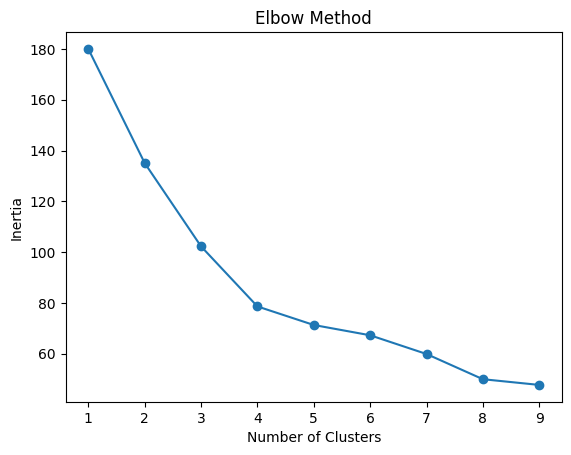

In [13]:
plt.plot(range(1,10),inertias, marker = "o")
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

Графік показує, що так званий лікоть(найбільш нахилена дуга) на 3 - після цього точки падають повільніше. Запустимо K-Means з трьома кластерами.

In [16]:
kmeans = KMeans(n_clusters=3, random_state = 42)
teachers["cluster"] = kmeans.fit_predict(X)
print(teachers.groupby("cluster")[["avg_grade","lessons_count","courses_count"]].mean())

         avg_grade  lessons_count  courses_count
cluster                                         
0        75.410367      17.185658      15.375000
1        74.955542      16.635563      16.619048
2        74.602721      17.290167      16.652174


Університет має збалансоване навантаження між викладачами - позитивний інсайт, адже всі кластери між собою схожі. Оцінки є практично однаковими, значення коливаються між 74.9 - 75.4. Навантаження також є рівномірним,  приблизно 16-17 курсів. Викладачі розподілені дуже однорідно. Суттєвих викидів чи перенавантаження викладачів немає.

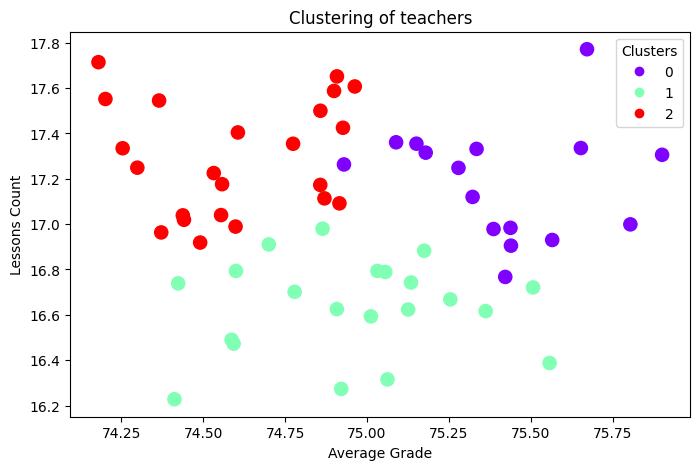

In [28]:
plt.figure(figsize = (8,5))
scatter = plt.scatter(teachers["avg_grade"], teachers["lessons_count"], c = teachers["cluster"], cmap = "rainbow", s = 90)
plt.xlabel("Average Grade")
plt.ylabel("Lessons Count")
plt.title("Clustering of teachers")
legend = plt.legend(*scatter.legend_elements(), title="Clusters")
plt.show()

# Висновок:
Аналіз 60 викладачів виявив 3 кластери:
Кластер 0 - викладачі з найвищими оцінками студентів (75.4) і середньою кількістю уроків (17.2). Найефективніша група.
Кластер 1 - найменше уроків (16.6) і найнижчі оцінки (74.6). Менш навантажена група.
Кластер 2 - найбільше уроків (17.3) але середні оцінки (75.0). Найбільш навантажена група.
Різниця між кластерами мінімальна -  університет має збалансоване навантаження і стабільну якість викладання. Це позитивний результат для платформи.